## Environment Setup
Core libraries for EDA, statistical testing, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

FIGURE_DIR = r"C:\Users\sharg\Desktop\github\DriftSentinel\outputs\figure"
DATA_PATH  = r"C:\Users\sharg\Desktop\github\DriftSentinel\data\raw\diabetes_hospital\diabetic_data.csv"
MAP_PATH   = r"C:\Users\sharg\Desktop\github\DriftSentinel\data\raw\diabetes_hospital\IDS_mapping.csv"

import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print("All libraries loaded.")
print(f"Figure output: {FIGURE_DIR}")

All libraries loaded.
Figure output: C:\Users\sharg\Desktop\github\DriftSentinel\outputs\figure


## 1. Data Loading
Load raw CSV. Replace sentinel `?` with NaN immediately upon ingestion.

In [2]:
df = pd.read_csv(DATA_PATH, na_values='?', low_memory=False)

print(f"Shape         : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDtype summary:")
print(df.dtypes.value_counts())

Shape         : (101766, 50)
Rows          : 101,766
Columns       : 50
Memory usage  : 48.51 MB

Dtype summary:
str      37
int64    13
Name: count, dtype: int64


## 2. Column Inventory
Full schema: dtype, non-null count, null count, null rate, and unique values per column.

In [3]:
inventory = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notna().sum(),
    'null_count' : df.isna().sum(),
    'null_pct'   : (df.isna().sum() / len(df) * 100).round(2),
    'n_unique'   : df.nunique(),
    'sample_val' : [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})

inventory = inventory.sort_values('null_pct', ascending=False)
print(inventory.to_string())

                          dtype  non_null  null_count  null_pct  n_unique                sample_val
weight                      str      3197       98569   96.8600         9                  [75-100)
max_glu_serum               str      5346       96420   94.7500         3                      >300
A1Cresult                   str     17018       84748   83.2800         3                        >7
medical_specialty           str     51817       49949   49.0800        72  Pediatrics-Endocrinology
payer_code                  str     61510       40256   39.5600        17                        MC
race                        str     99493        2273    2.2300         5                 Caucasian
diag_3                      str    100343        1423    1.4000       789                       255
diag_2                      str    101408         358    0.3500       748                    250.01
diag_1                      str    101745          21    0.0200       716                    250.83


## 3. Target Variable Analysis
`readmitted` has 3 classes: NO, <30, >30. Class balance determines modeling strategy and drift detection reference distribution.

=== Target Distribution ===
            count     pct
readmitted               
NO          54864 53.9100
>30         35545 34.9300
<30         11357 11.1600


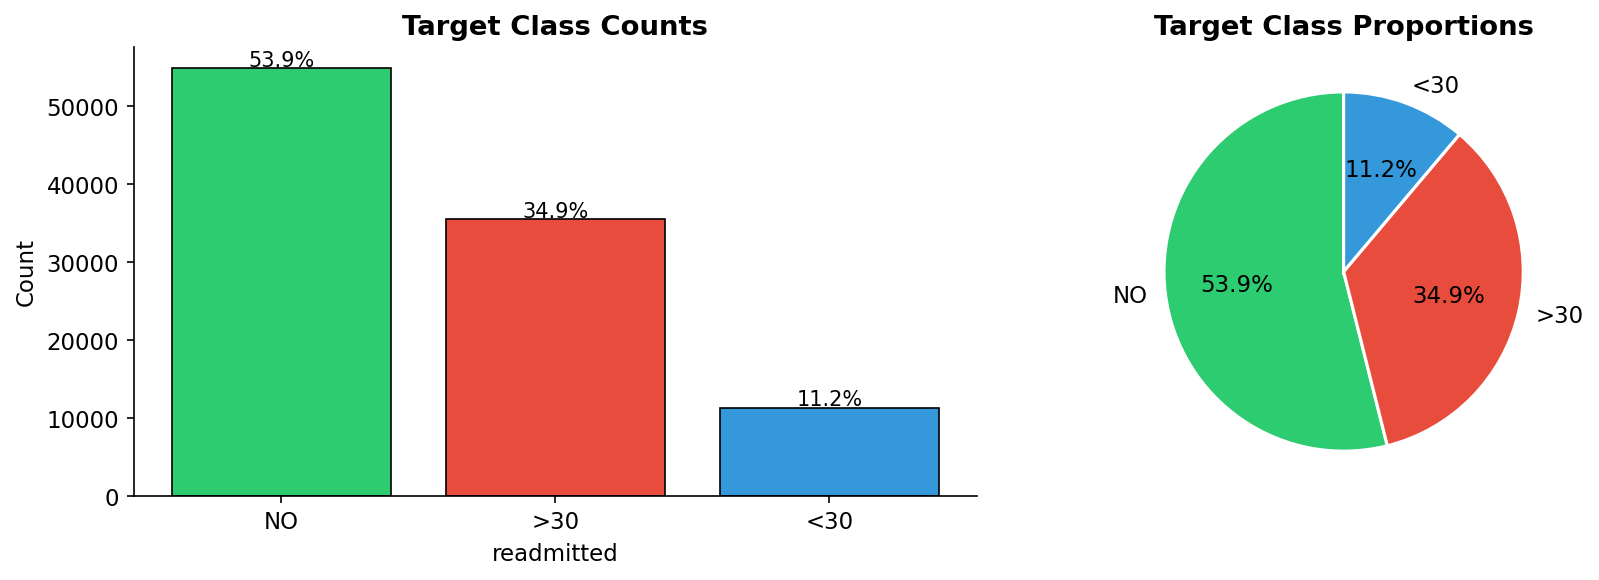

Saved: 01_target_distribution.png


In [4]:
target_counts = df['readmitted'].value_counts()
target_pct    = df['readmitted'].value_counts(normalize=True) * 100

print("=== Target Distribution ===")
print(pd.DataFrame({'count': target_counts, 'pct': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(target_counts.index, target_counts.values,
            color=['#2ecc71','#e74c3c','#3498db'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Class Counts', fontweight='bold')
axes[0].set_xlabel('readmitted')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 200, f'{p:.1f}%', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c','#3498db'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Target Class Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/01_target_distribution.png", bbox_inches='tight')
plt.show()
print("Saved: 01_target_distribution.png")

## 4. Missing Value Analysis
Columns with any missingness ranked by null rate. Critical for imputation strategy and drift simulation.

Columns with missing values: 9
                   null_count  null_pct  n_unique
weight                  98569   96.8600         9
max_glu_serum           96420   94.7500         3
A1Cresult               84748   83.2800         3
medical_specialty       49949   49.0800        72
payer_code              40256   39.5600        17
race                     2273    2.2300         5
diag_3                   1423    1.4000       789
diag_2                    358    0.3500       748
diag_1                     21    0.0200       716


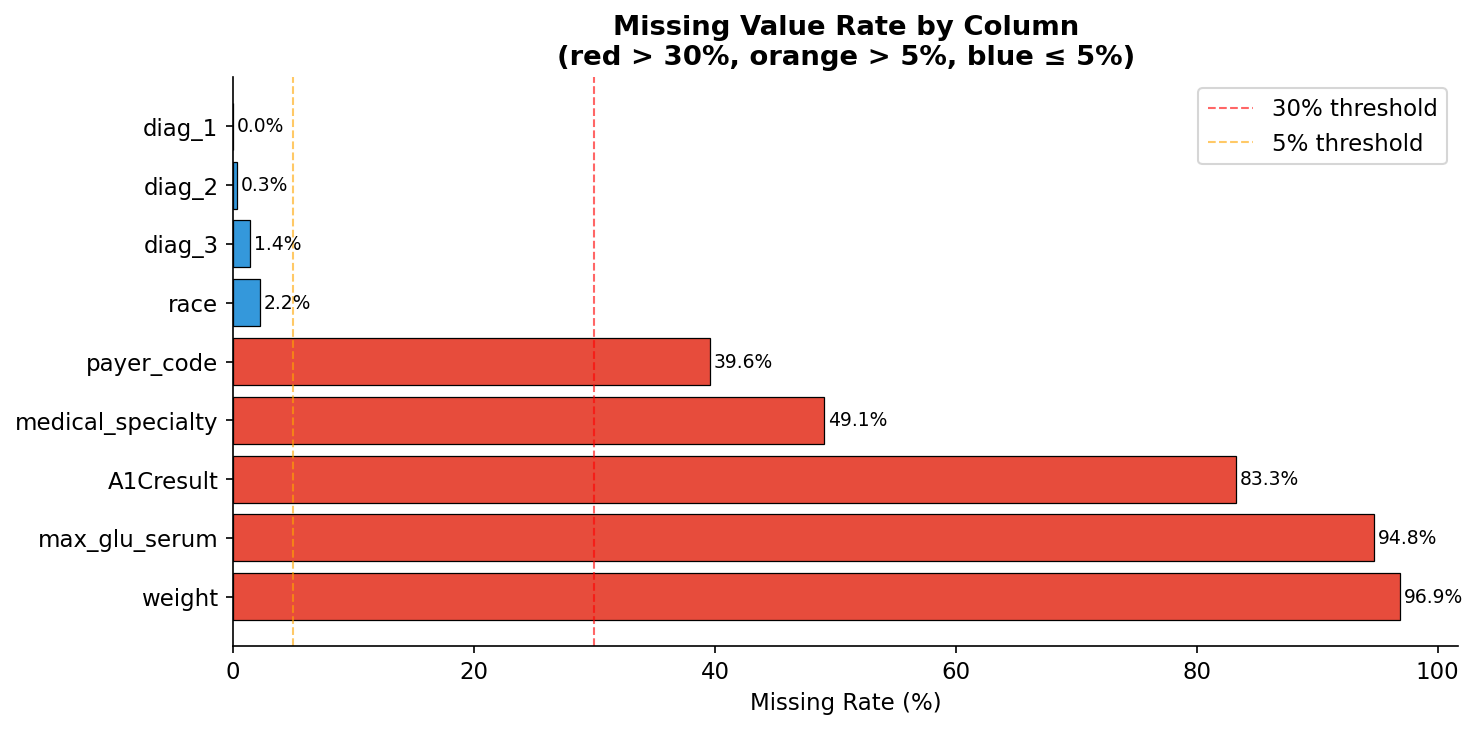

Saved: 02_missing_values.png


In [5]:
null_df = inventory[inventory['null_count'] > 0][['null_count','null_pct','n_unique']].copy()
print(f"Columns with missing values: {len(null_df)}")
print(null_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if p > 30 else '#f39c12' if p > 5 else '#3498db'
          for p in null_df['null_pct']]
bars = ax.barh(null_df.index, null_df['null_pct'], color=colors, edgecolor='black', linewidth=0.6)
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Missing Value Rate by Column\n(red > 30%, orange > 5%, blue ≤ 5%)', fontweight='bold')
ax.axvline(30, color='red', linestyle='--', linewidth=1, alpha=0.6, label='30% threshold')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1, alpha=0.6, label='5% threshold')
ax.legend()
for bar, val in zip(bars, null_df['null_pct']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/02_missing_values.png", bbox_inches='tight')
plt.show()
print("Saved: 02_missing_values.png")

## 5. Duplicate & Patient ID Integrity
`encounter_id` must be globally unique. `patient_nbr` may repeat (same patient, multiple visits). Repeated visits introduce label correlation — critical for drift simulation splits.

In [6]:
print("=== Duplicate Integrity ===")
print(f"Total rows              : {len(df):,}")
print(f"Unique encounter_id     : {df['encounter_id'].nunique():,}")
print(f"Duplicate encounter_id  : {df.duplicated('encounter_id').sum():,}")
print(f"Unique patient_nbr      : {df['patient_nbr'].nunique():,}")

visit_counts = df['patient_nbr'].value_counts()
print(f"\nPatient visit distribution:")
print(visit_counts.value_counts().sort_index().rename_axis('n_visits').reset_index(name='n_patients').head(10).to_string(index=False))

multi_visit_patients = (visit_counts > 1).sum()
multi_visit_pct = multi_visit_patients / df['patient_nbr'].nunique() * 100
print(f"\nPatients with >1 visit : {multi_visit_patients:,} ({multi_visit_pct:.1f}%)")

=== Duplicate Integrity ===
Total rows              : 101,766
Unique encounter_id     : 101,766
Duplicate encounter_id  : 0
Unique patient_nbr      : 71,518

Patient visit distribution:
 n_visits  n_patients
        1       54745
        2       10434
        3        3328
        4        1421
        5         717
        6         346
        7         207
        8         111
        9          70
       10          42

Patients with >1 visit : 16,773 (23.5%)


## 6. Numeric Feature Distributions
Statistical summary + distribution shape for all 13 integer columns. Skewness and kurtosis flag candidates for transformation.

In [7]:
num_cols = df.select_dtypes(include='int64').columns.tolist()
print(f"Numeric columns ({len(num_cols)}): {num_cols}\n")

stats_df = df[num_cols].describe().T
stats_df['skewness'] = df[num_cols].skew()
stats_df['kurtosis'] = df[num_cols].kurt()
stats_df['cv']       = stats_df['std'] / stats_df['mean'].abs()
print(stats_df[['mean','std','min','25%','50%','75%','max','skewness','kurtosis','cv']].to_string())

Numeric columns (13): ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

                                   mean            std        min           25%            50%            75%            max  skewness  kurtosis     cv
encounter_id             165201645.6230 102640295.9835 12522.0000 84961194.0000 152388987.0000 230270887.5000 443867222.0000    0.6991   -0.1021 0.6213
patient_nbr               54330400.6949  38696359.3465   135.0000 23413221.0000  45505143.0000  87545949.7500 189502619.0000    0.4713   -0.3474 0.7122
admission_type_id                2.0240         1.4454     1.0000        1.0000         1.0000         3.0000         8.0000    1.5920    1.9425 0.7141
discharge_disposition_id         3.7156         5.2802     1.0000        1.0000         1.0000         4.

## 7. Numeric Feature Histograms
Distribution shape per feature. Red dashed line = median. Highly skewed features signal outliers and require attention before modeling.

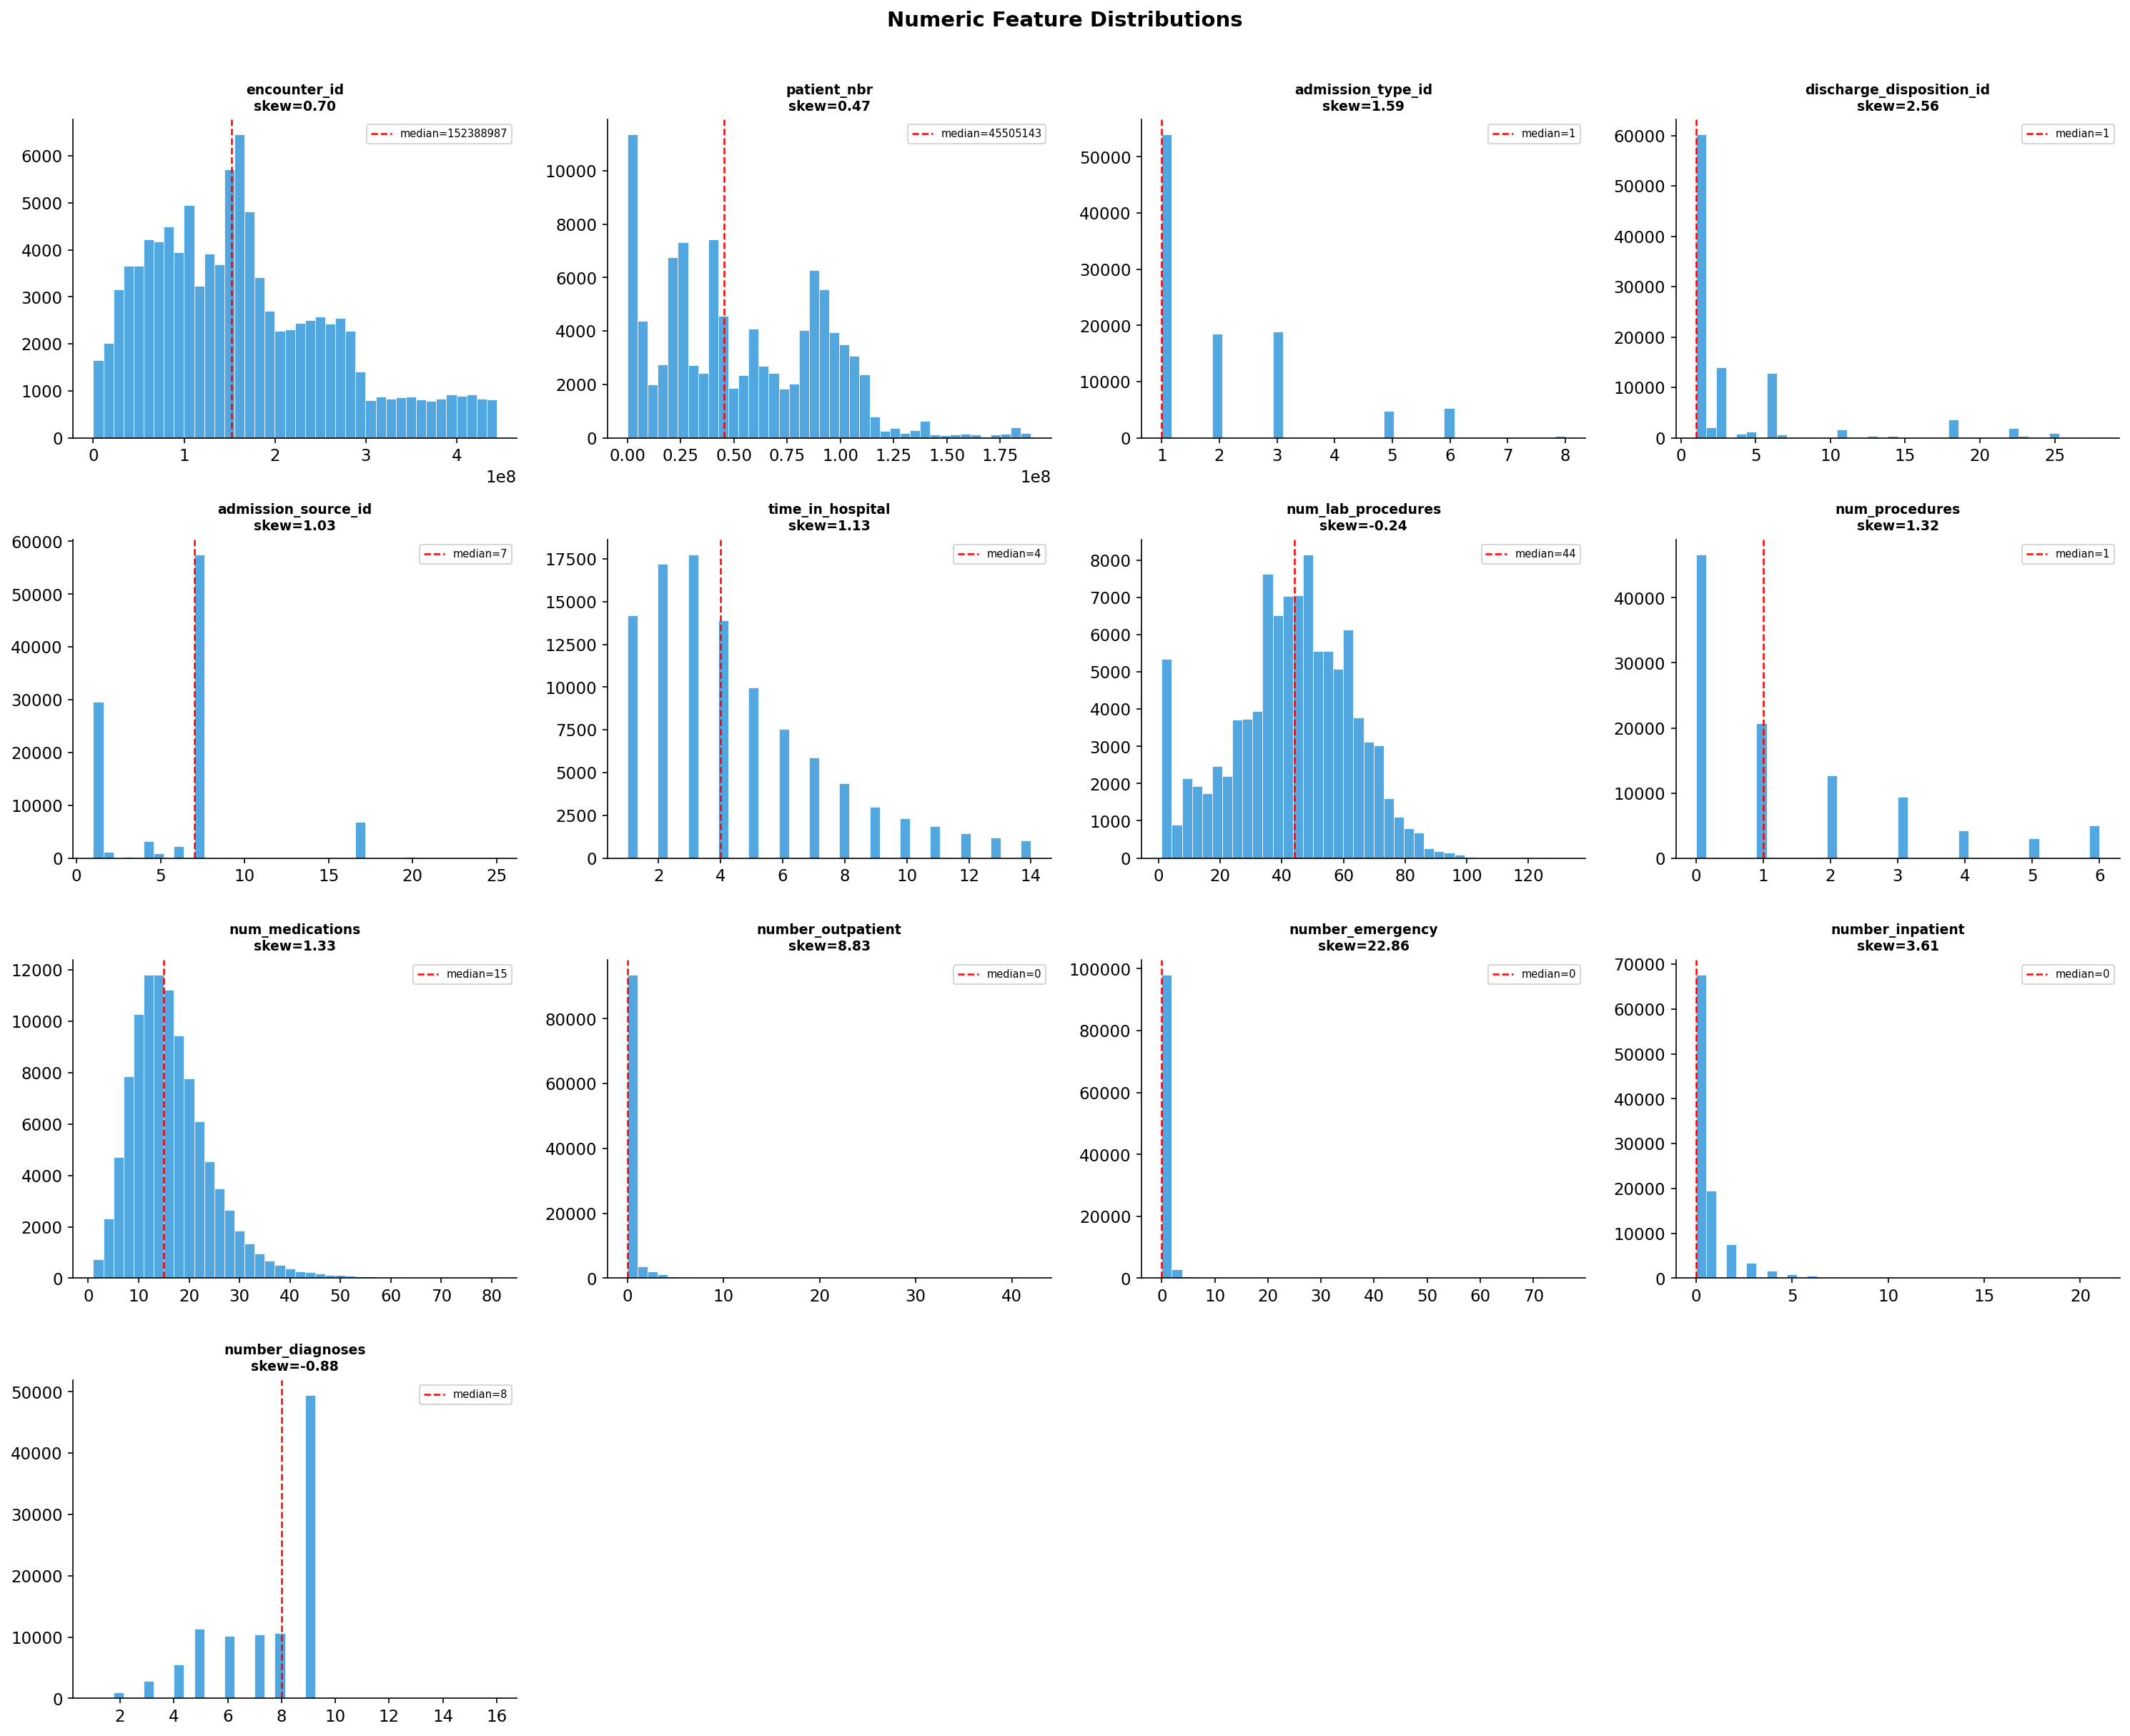

Saved: 03_numeric_distributions.png


In [8]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color='#3498db', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'median={data.median():.0f}')
    ax.set_title(f'{col}\nskew={data.skew():.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/03_numeric_distributions.png", bbox_inches='tight')
plt.show()
print("Saved: 03_numeric_distributions.png")

## 8. Numeric Features vs Target (Kruskal-Wallis Test)
Non-parametric test for distributional difference across readmission classes. H-statistic and p-value determine feature discriminability.

=== Kruskal-Wallis: Numeric Features vs readmitted ===
                 feature  H_statistic  p_value  significant
        number_inpatient    5662.5106   0.0000         True
        number_emergency    1651.9502   0.0000         True
       number_outpatient    1252.1452   0.0000         True
        number_diagnoses    1209.9767   0.0000         True
             patient_nbr     857.4417   0.0000         True
         num_medications     547.5385   0.0000         True
        time_in_hospital     469.2363   0.0000         True
discharge_disposition_id     443.8165   0.0000         True
     admission_source_id     376.2362   0.0000         True
          num_procedures     235.0932   0.0000         True
      num_lab_procedures     173.4166   0.0000         True
       admission_type_id      52.0622   0.0000         True
            encounter_id      49.6722   0.0000         True


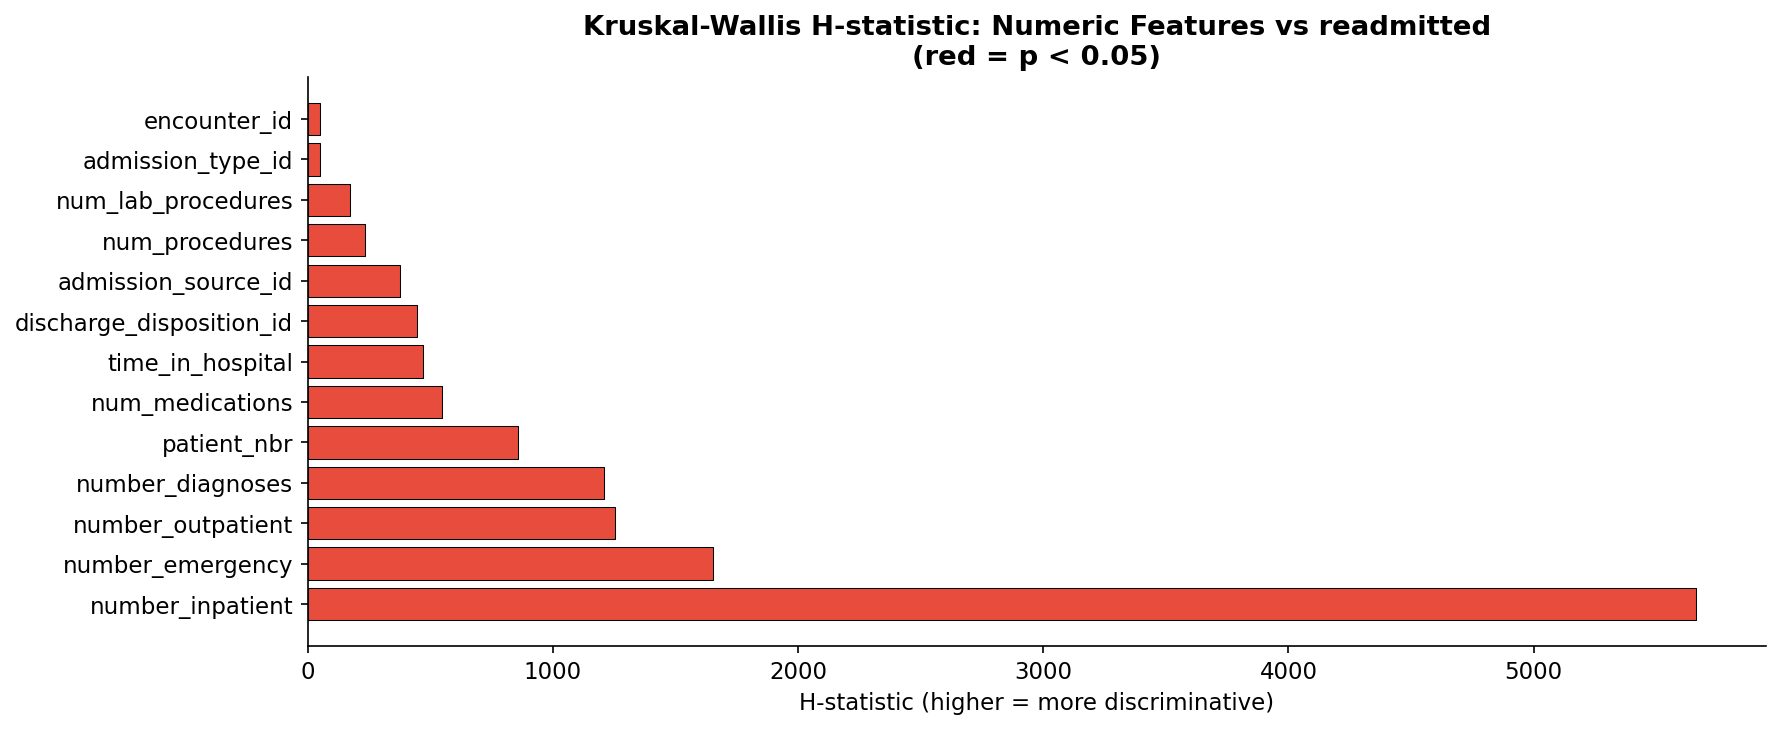

Saved: 04_kruskal_wallis_numeric.png


In [9]:
from scipy.stats import kruskal

results = []
groups_map = {cls: df[df['readmitted'] == cls] for cls in df['readmitted'].unique()}

for col in num_cols:
    groups = [g[col].dropna().values for g in groups_map.values()]
    try:
        h_stat, p_val = kruskal(*groups)
    except Exception:
        h_stat, p_val = np.nan, np.nan
    results.append({'feature': col, 'H_statistic': h_stat, 'p_value': p_val,
                    'significant': p_val < 0.05})

kw_df = pd.DataFrame(results).sort_values('H_statistic', ascending=False)
print("=== Kruskal-Wallis: Numeric Features vs readmitted ===")
print(kw_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if s else '#95a5a6' for s in kw_df['significant']]
ax.barh(kw_df['feature'], kw_df['H_statistic'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('H-statistic (higher = more discriminative)')
ax.set_title('Kruskal-Wallis H-statistic: Numeric Features vs readmitted\n(red = p < 0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/04_kruskal_wallis_numeric.png", bbox_inches='tight')
plt.show()
print("Saved: 04_kruskal_wallis_numeric.png")

## 9. Numeric Feature Correlation Matrix
Pearson correlation among integer features. High inter-feature correlation (|r| > 0.7) flags multicollinearity — relevant for feature selection and adversarial perturbation design.

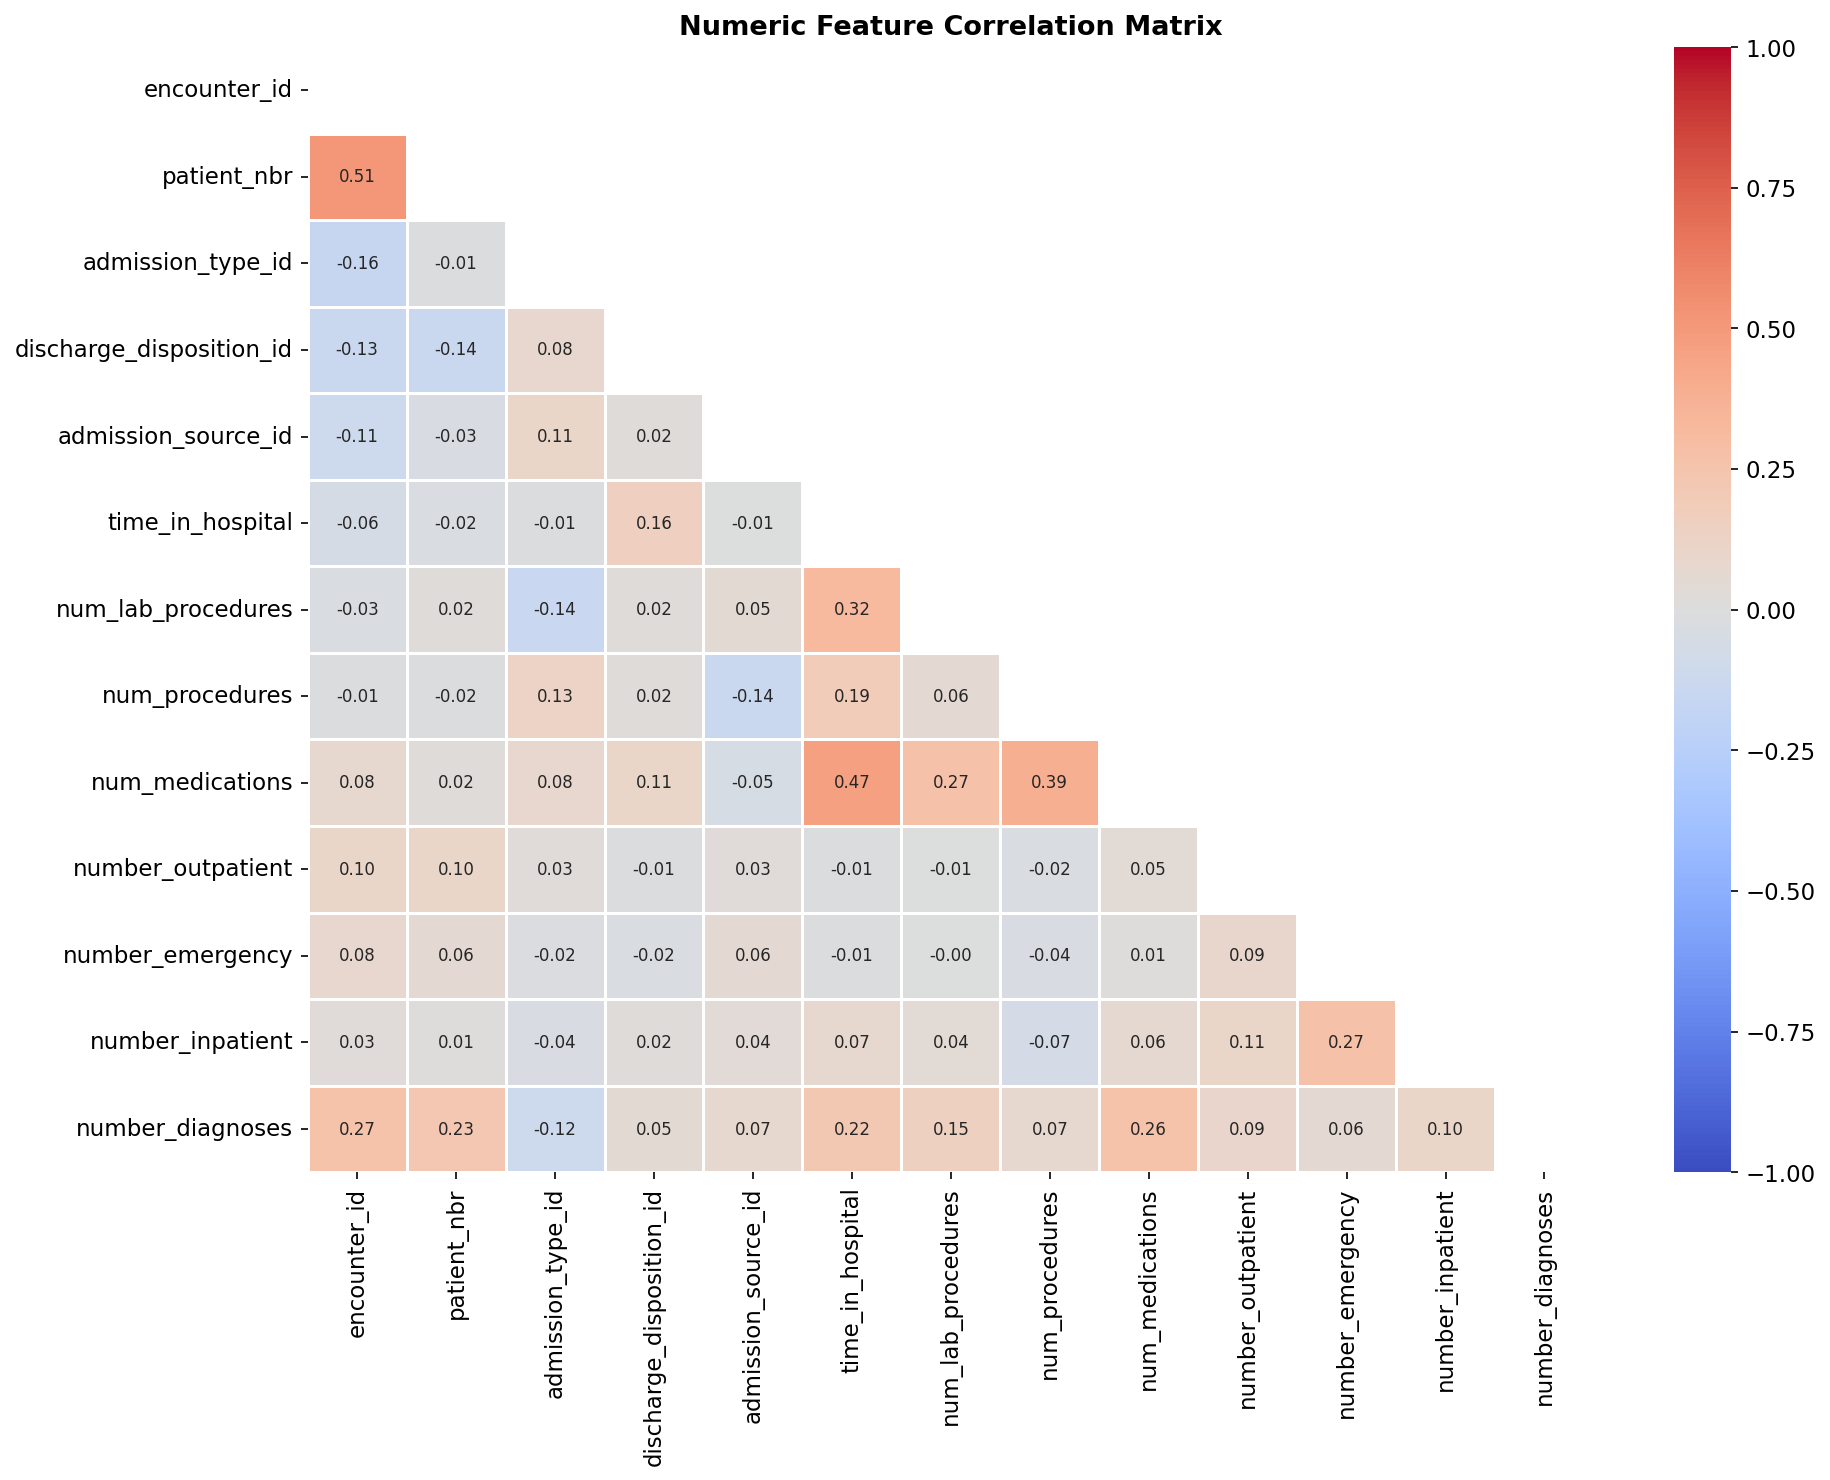

Pairs with |r| > 0.5:
       col_A       col_B      r
encounter_id patient_nbr 0.5120
Saved: 05_correlation_matrix.png


In [10]:
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Numeric Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/05_correlation_matrix.png", bbox_inches='tight')
plt.show()

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            high_corr.append({'col_A': corr.columns[i], 'col_B': corr.columns[j], 'r': round(r, 4)})

high_corr_df = pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False)
print("Pairs with |r| > 0.5:")
print(high_corr_df.to_string(index=False))
print("Saved: 05_correlation_matrix.png")

## 10. Categorical Feature Cardinality
Unique value count per string column. High-cardinality columns (diag_1/2/3, medical_specialty) require special encoding. Low-cardinality binary columns (change, diabetesMed) are drift-sensitive flags.

Categorical columns (37):

                          n_unique  null_pct         top_value top_freq
diag_3                         789    1.4000               250    11.4%
diag_2                         748    0.3500               276     6.6%
diag_1                         716    0.0200               428     6.7%
medical_specialty               72   49.0800  InternalMedicine    14.4%
payer_code                      17   39.5600                MC    31.9%
age                             10    0.0000           [70-80)    25.6%
weight                           9   96.8600          [75-100)     1.3%
race                             5    2.2300         Caucasian    74.8%
glyburide-metformin              4    0.0000                No    99.3%
repaglinide                      4    0.0000                No    98.5%
metformin                        4    0.0000                No    80.4%
chlorpropamide                   4    0.0000                No    99.9%
nateglinide                      4   

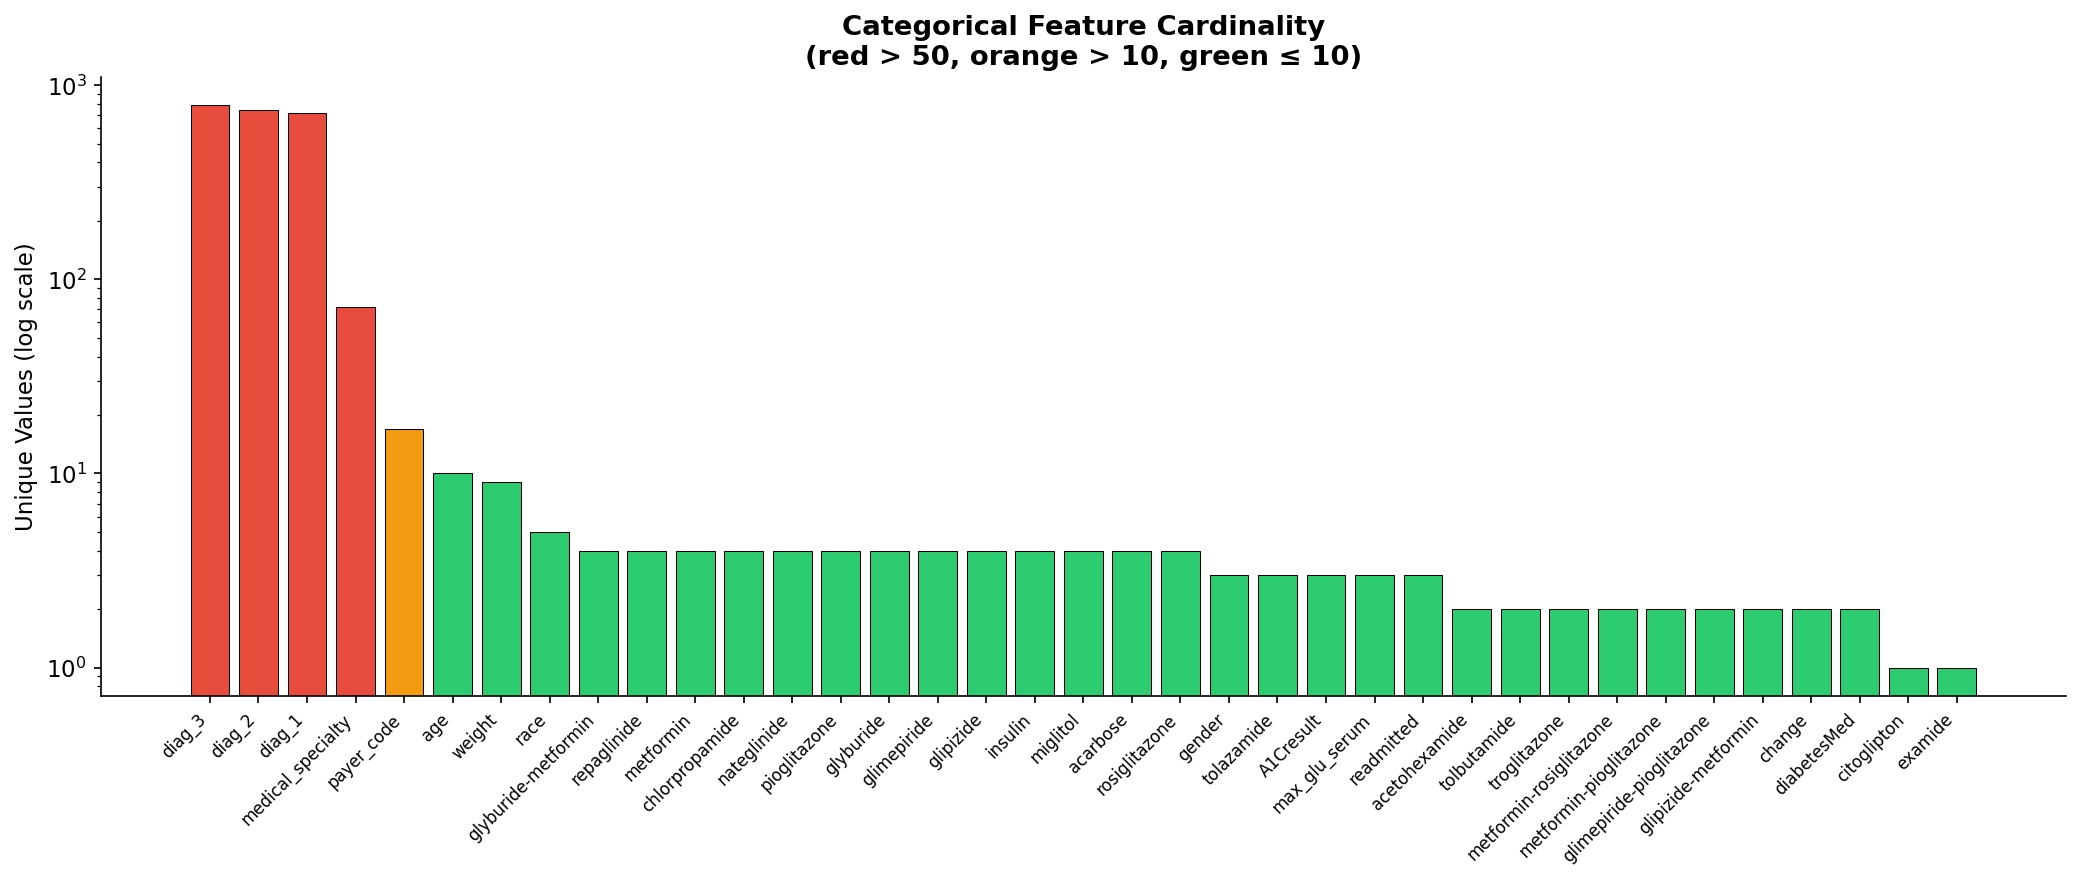

Saved: 06_categorical_cardinality.png


In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}):\n")

cat_info = pd.DataFrame({
    'n_unique' : df[cat_cols].nunique(),
    'null_pct' : (df[cat_cols].isna().sum() / len(df) * 100).round(2),
    'top_value': df[cat_cols].apply(lambda c: c.value_counts().index[0] if c.notna().any() else None),
    'top_freq' : df[cat_cols].apply(lambda c: f"{c.value_counts().iloc[0]/len(df)*100:.1f}%" if c.notna().any() else None)
}).sort_values('n_unique', ascending=False)

print(cat_info.to_string())

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if n > 50 else '#f39c12' if n > 10 else '#2ecc71'
          for n in cat_info['n_unique']]
ax.bar(cat_info.index, cat_info['n_unique'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticklabels(cat_info.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Unique Values (log scale)')
ax.set_yscale('log')
ax.set_title('Categorical Feature Cardinality\n(red > 50, orange > 10, green ≤ 10)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/06_categorical_cardinality.png", bbox_inches='tight')
plt.show()
print("Saved: 06_categorical_cardinality.png")

## 11. Demographic Features: Race, Gender, Age
Distribution and readmission rate by demographic group. Chi-square test for independence vs target. Demographic drift between time windows is a primary DriftSentinel use case.

race: chi2=282.59, p=7.3795e-55, dof=10 — SIGNIFICANT
gender: chi2=37.46, p=1.4473e-07, dof=4 — SIGNIFICANT
age: chi2=313.17, p=9.3484e-56, dof=18 — SIGNIFICANT


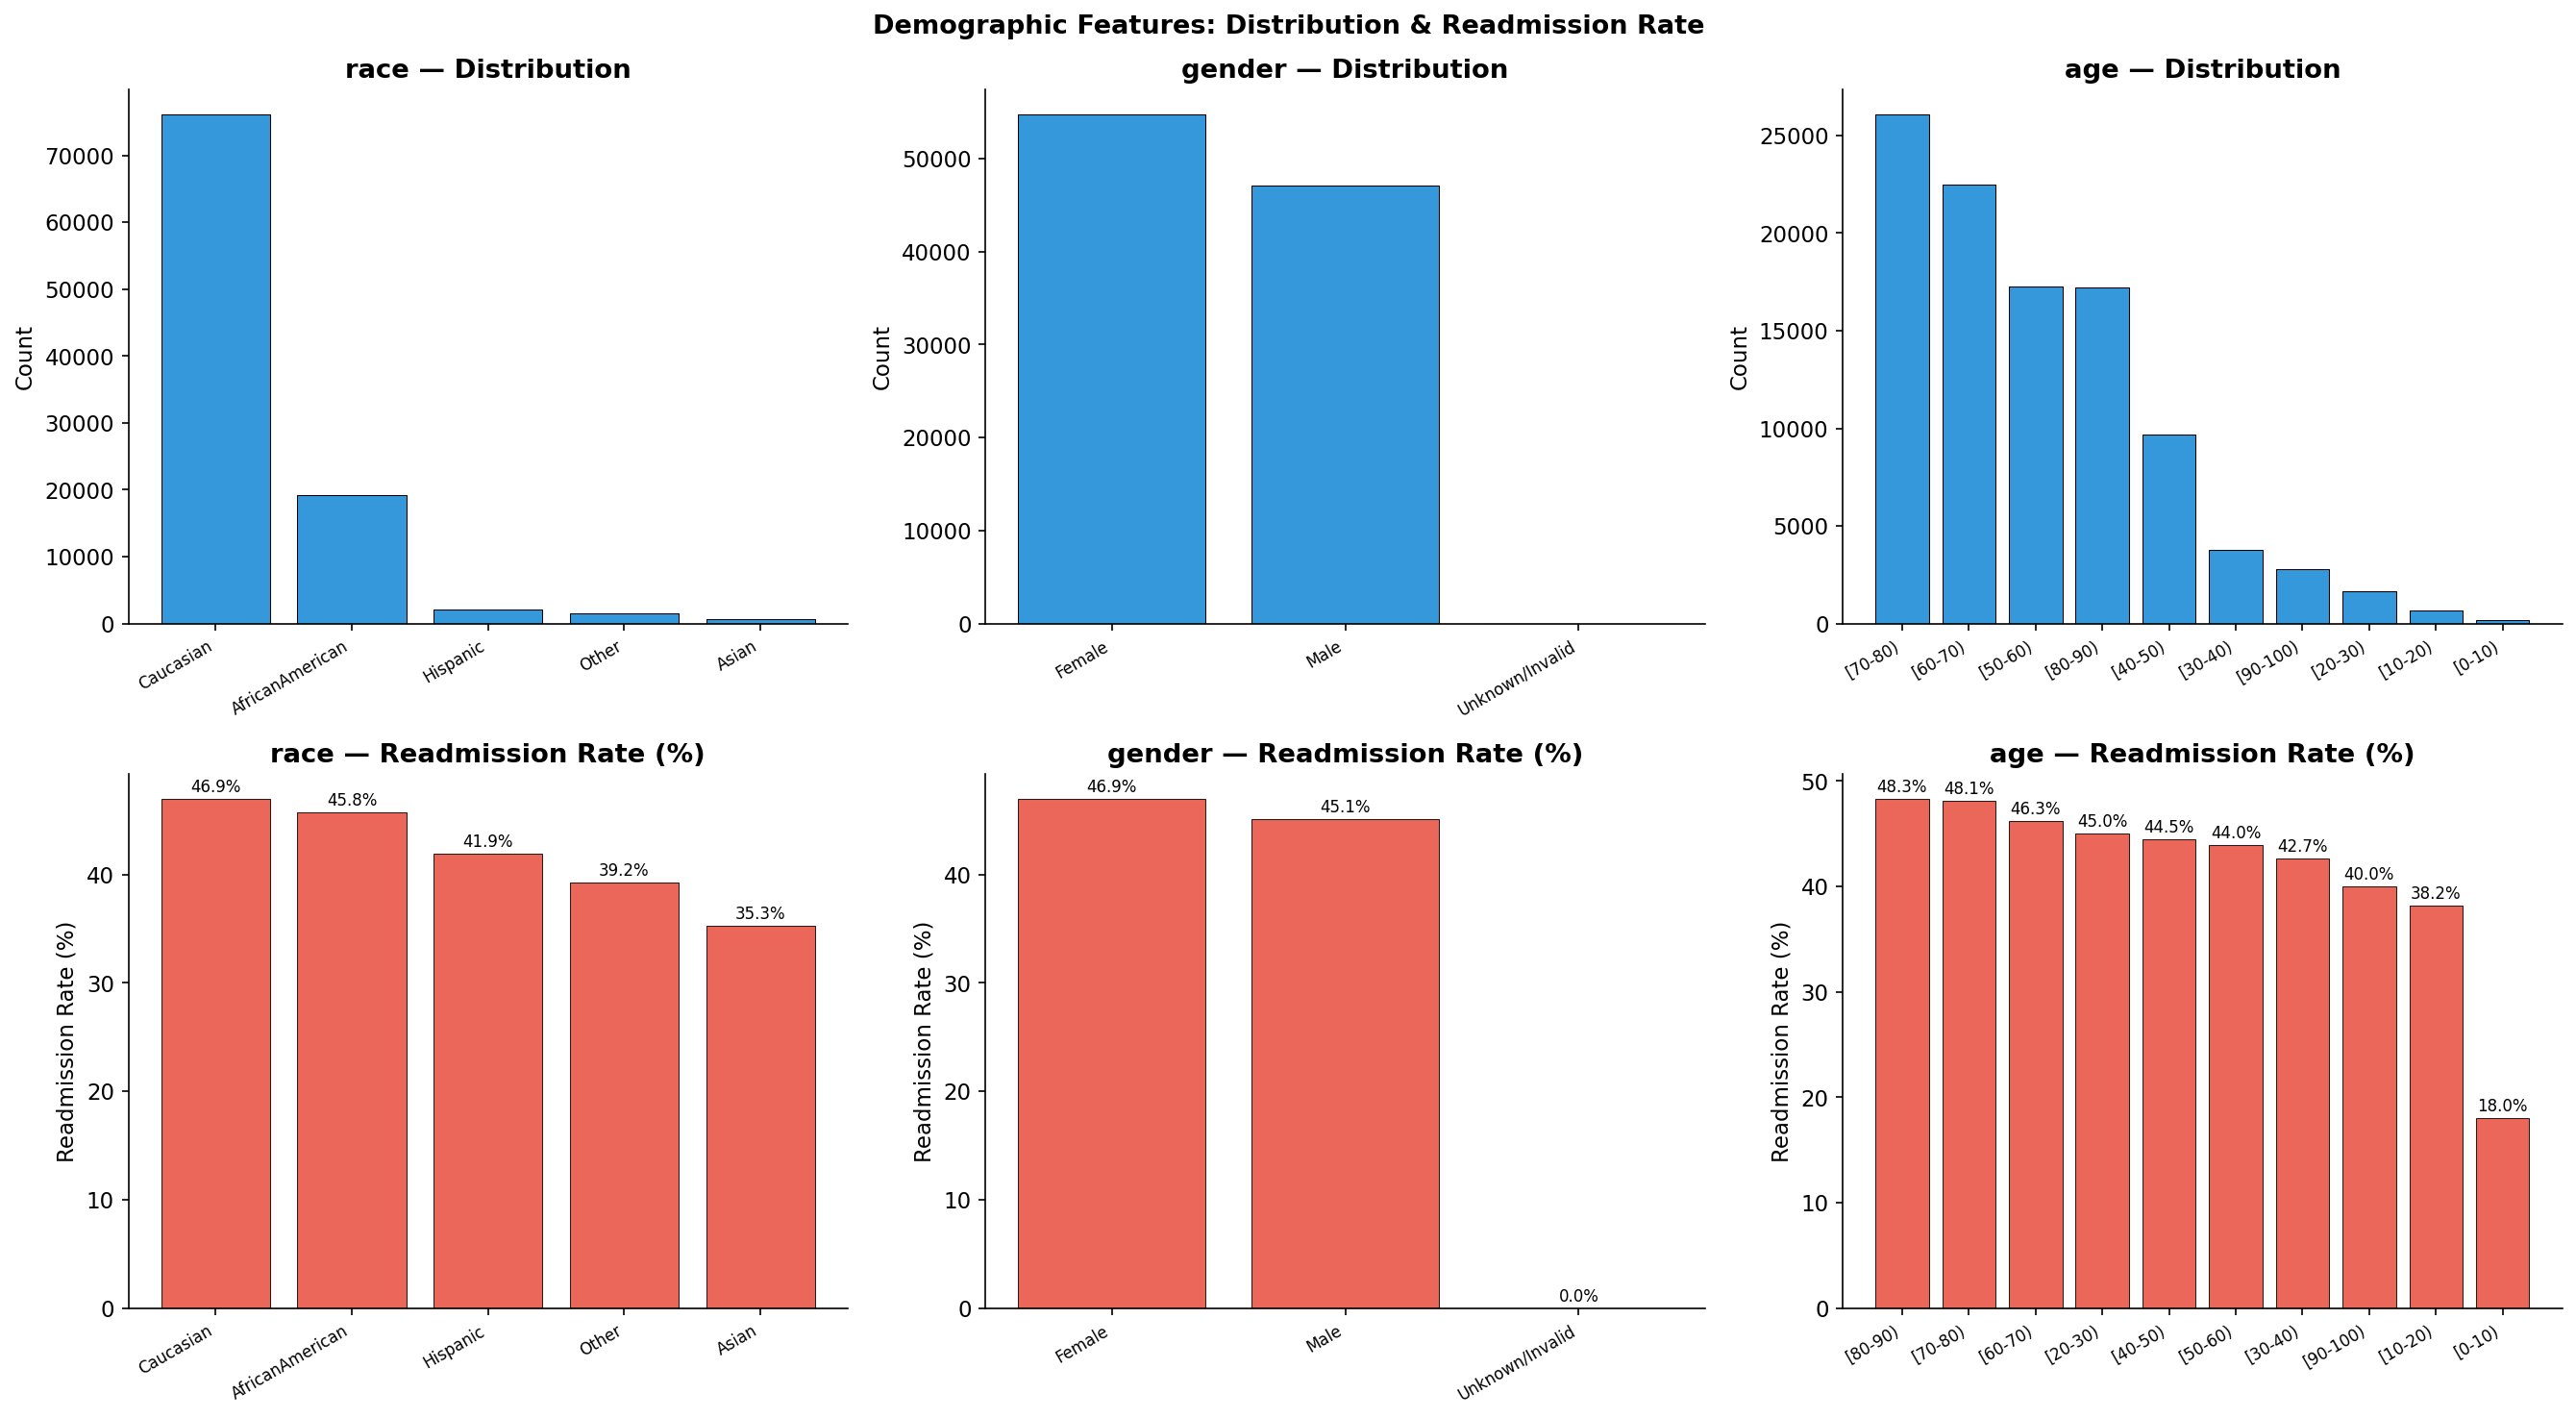

Saved: 07_demographic_analysis.png


In [12]:
demo_cols = ['race', 'gender', 'age']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_i, col in enumerate(demo_cols):
    # Top row: count distribution
    ax = axes[0, col_i]
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color='#3498db', edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col} — Distribution', fontweight='bold')
    ax.set_xticklabels(vc.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Count')

    # Bottom row: readmission rate by group
    ax2 = axes[1, col_i]
    readmit_rate = df.groupby(col)['readmitted'].apply(
        lambda x: (x != 'NO').sum() / len(x) * 100
    ).sort_values(ascending=False)
    bars = ax2.bar(readmit_rate.index, readmit_rate.values,
                   color='#e74c3c', edgecolor='black', linewidth=0.5, alpha=0.85)
    ax2.set_title(f'{col} — Readmission Rate (%)', fontweight='bold')
    ax2.set_xticklabels(readmit_rate.index, rotation=30, ha='right', fontsize=8)
    ax2.set_ylabel('Readmission Rate (%)')
    for bar, val in zip(bars, readmit_rate.values):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

    # Chi-square test
    contingency = pd.crosstab(df[col].fillna('Unknown'), df['readmitted'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p={p:.4e}, dof={dof} — {'SIGNIFICANT' if p < 0.05 else 'not significant'}")

plt.suptitle('Demographic Features: Distribution & Readmission Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/07_demographic_analysis.png", bbox_inches='tight')
plt.show()
print("Saved: 07_demographic_analysis.png")

## 12. Medication Feature Analysis
23 medication columns encode dosage change: No / Steady / Up / Down. Medication change pattern is a strong clinical signal and a key drift indicator in production deployments.

=== Medication Usage Summary ===
                           No_pct  Steady_pct  Up_pct  Down_pct  prescribed_pct
insulin                   46.5600     30.3100 11.1200   12.0100         53.4400
metformin                 80.3600     18.0300  1.0500    0.5700         19.6400
glipizide                 87.5300     11.1600  0.7600    0.5500         12.4700
glyburide                 89.5300      9.1100  0.8000    0.5500         10.4700
pioglitazone              92.8000      6.8500  0.2300    0.1200          7.2000
rosiglitazone             93.7500      5.9900  0.1700    0.0900          6.2500
glimepiride               94.9000      4.5900  0.3200    0.1900          5.1000
repaglinide               98.4900      1.3600  0.1100    0.0400          1.5100
glyburide-metformin       99.3100      0.6800  0.0100    0.0100          0.6900
nateglinide               99.3100      0.6600  0.0200    0.0100          0.6900
acarbose                  99.7000      0.2900  0.0100    0.0000          0.3000
chlorpr

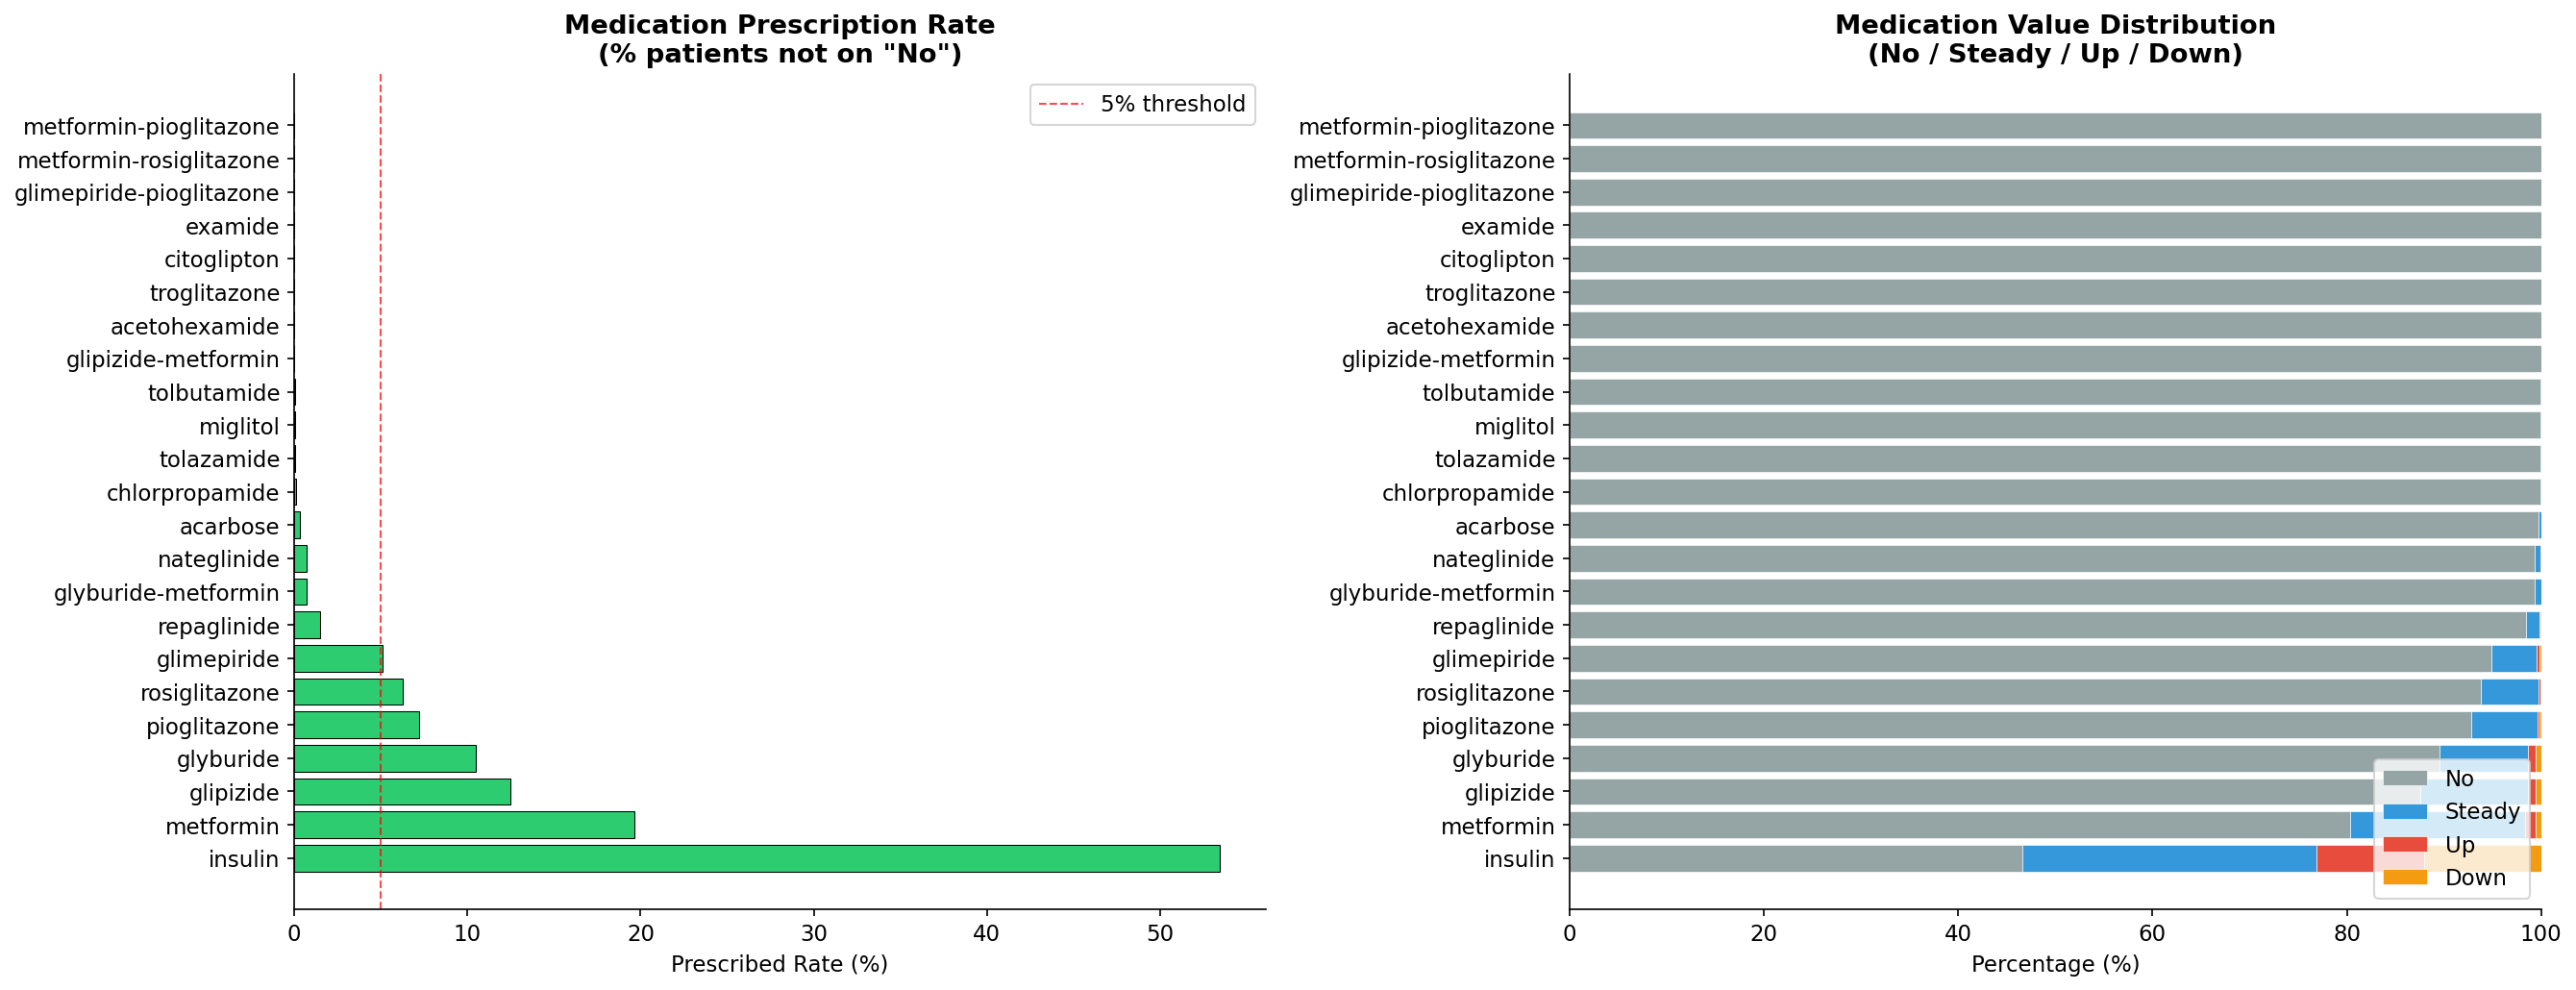

Saved: 08_medication_analysis.png


In [13]:
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
            'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
            'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
            'examide','citoglipton','insulin','glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']

med_summary = pd.DataFrame({
    'No_pct'     : (df[med_cols] == 'No').sum() / len(df) * 100,
    'Steady_pct' : (df[med_cols] == 'Steady').sum() / len(df) * 100,
    'Up_pct'     : (df[med_cols] == 'Up').sum() / len(df) * 100,
    'Down_pct'   : (df[med_cols] == 'Down').sum() / len(df) * 100,
}).round(2)
med_summary['prescribed_pct'] = 100 - med_summary['No_pct']
med_summary = med_summary.sort_values('prescribed_pct', ascending=False)

print("=== Medication Usage Summary ===")
print(med_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Prescription rate
axes[0].barh(med_summary.index, med_summary['prescribed_pct'],
             color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Prescribed Rate (%)')
axes[0].set_title('Medication Prescription Rate\n(% patients not on "No")', fontweight='bold')
axes[0].axvline(5, color='red', linestyle='--', linewidth=1, alpha=0.7, label='5% threshold')
axes[0].legend()

# Stacked bar: value distribution
bottom_vals = np.zeros(len(med_summary))
colors_stack = ['#95a5a6','#3498db','#e74c3c','#f39c12']
labels_stack = ['No','Steady','Up','Down']
for lbl, color in zip(labels_stack, colors_stack):
    col_key = f'{lbl}_pct'
    axes[1].barh(med_summary.index, med_summary[col_key],
                 left=bottom_vals, color=color, label=lbl, edgecolor='white', linewidth=0.3)
    bottom_vals += med_summary[col_key].values

axes[1].set_xlabel('Percentage (%)')
axes[1].set_title('Medication Value Distribution\n(No / Steady / Up / Down)', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/08_medication_analysis.png", bbox_inches='tight')
plt.show()
print("Saved: 08_medication_analysis.png")

## 13. Primary Diagnosis (diag_1) Analysis
Top ICD-9 codes by frequency. Diagnosis distribution shift is a primary concept drift indicator in clinical ML systems.

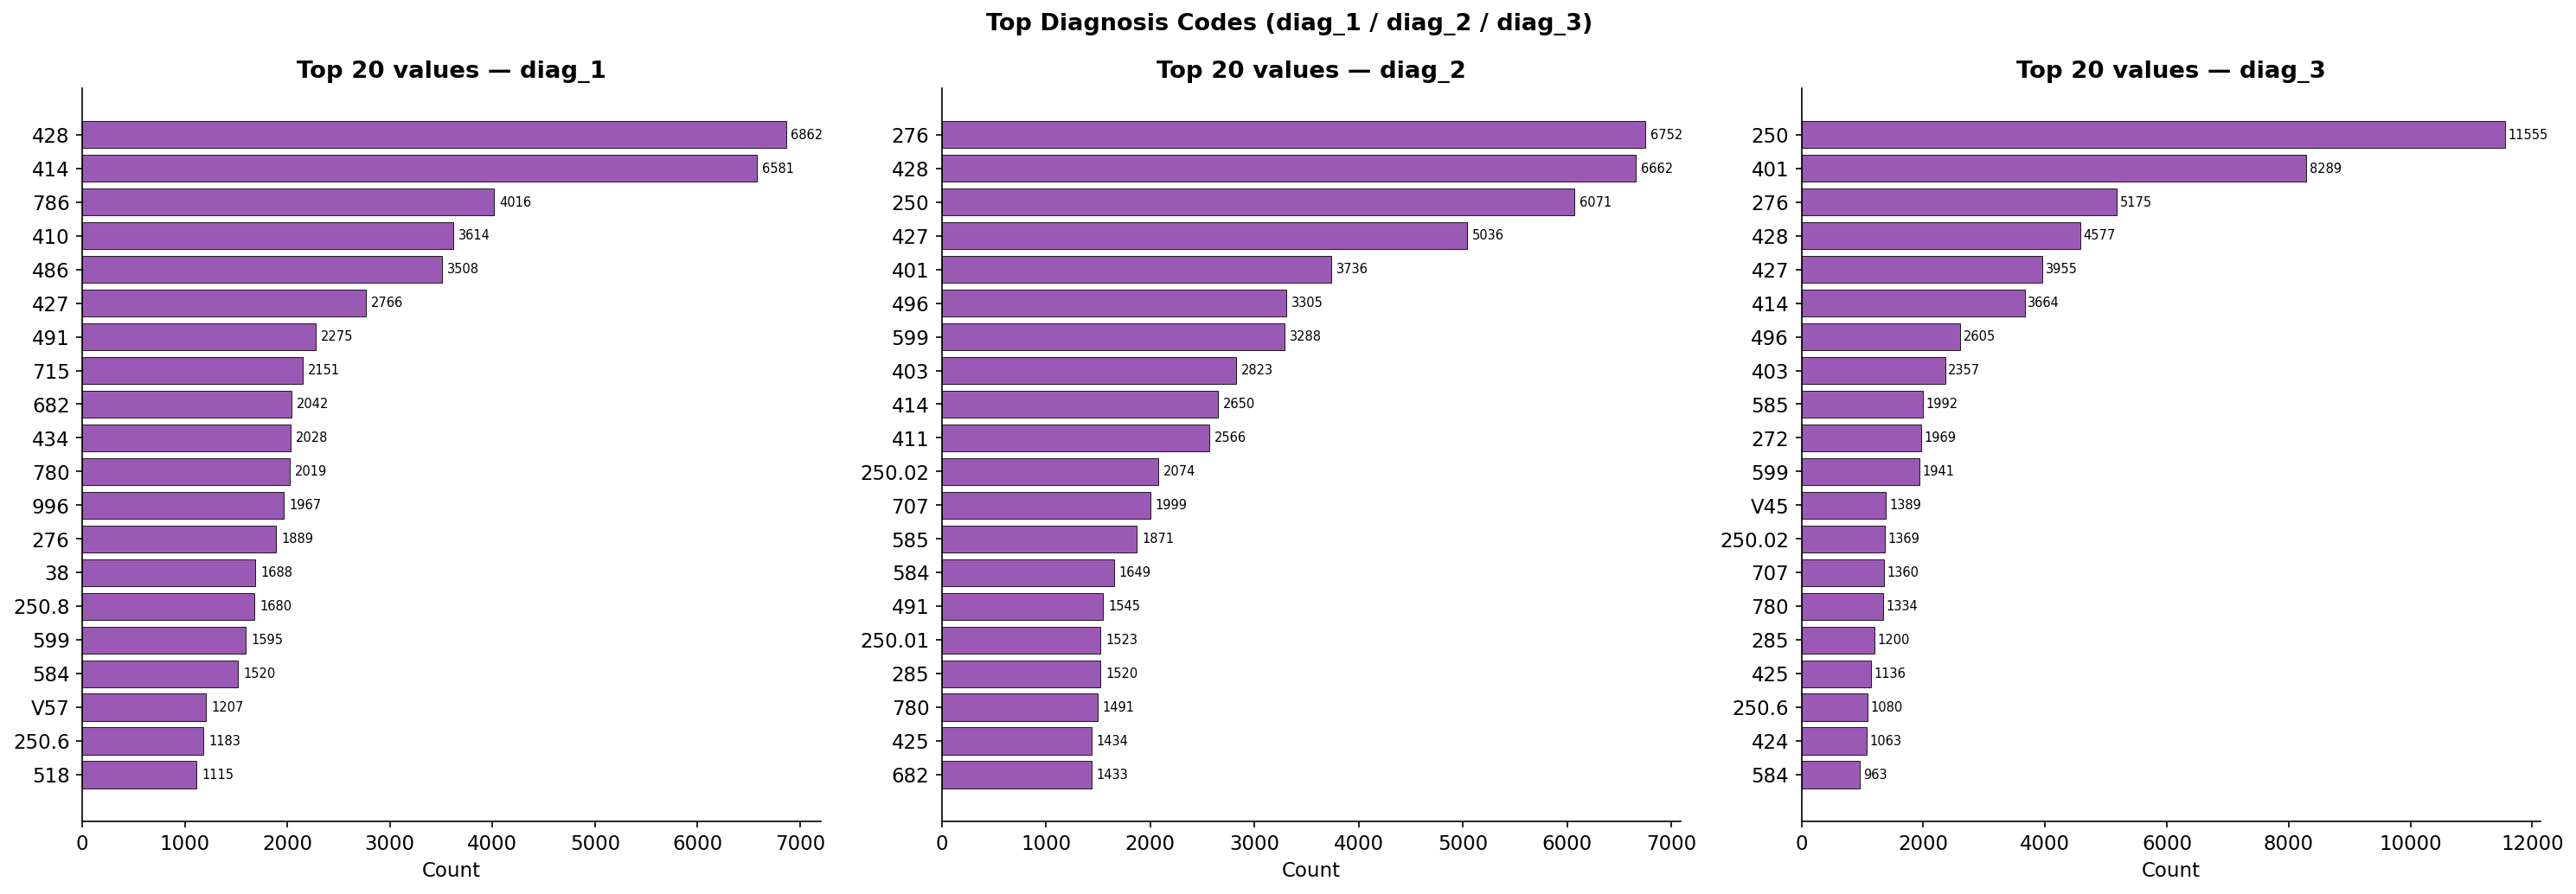

Rows with primary diabetes diagnosis (250.x): 8,757 (8.6%)
Saved: 09_diagnosis_codes.png


In [14]:
top_n = 20

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, col in zip(axes, ['diag_1', 'diag_2', 'diag_3']):
    vc = df[col].value_counts().head(top_n)
    ax.barh(vc.index[::-1], vc.values[::-1], color='#9b59b6', edgecolor='black', linewidth=0.4)
    ax.set_title(f'Top {top_n} values — {col}', fontweight='bold')
    ax.set_xlabel('Count')
    for i, (val, cnt) in enumerate(zip(vc.index[::-1], vc.values[::-1])):
        ax.text(cnt + 50, i, str(cnt), va='center', fontsize=7)

plt.suptitle('Top Diagnosis Codes (diag_1 / diag_2 / diag_3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/09_diagnosis_codes.png", bbox_inches='tight')
plt.show()

# Diabetes-related diagnosis check
diabetes_codes = df['diag_1'].astype(str).str.startswith('250')
print(f"Rows with primary diabetes diagnosis (250.x): {diabetes_codes.sum():,} ({diabetes_codes.mean()*100:.1f}%)")
print("Saved: 09_diagnosis_codes.png")

## 14. Admission Type, Discharge Disposition & Admission Source
These administrative features encode patient flow. Distribution shift in admission patterns signals operational drift — distinct from clinical concept drift.

admission_type_id: chi2=415.76, p=6.0375e-80 — SIGNIFICANT
discharge_disposition_id: chi2=3587.29, p=0.0000e+00 — SIGNIFICANT
admission_source_id: chi2=1150.97, p=2.3180e-221 — SIGNIFICANT


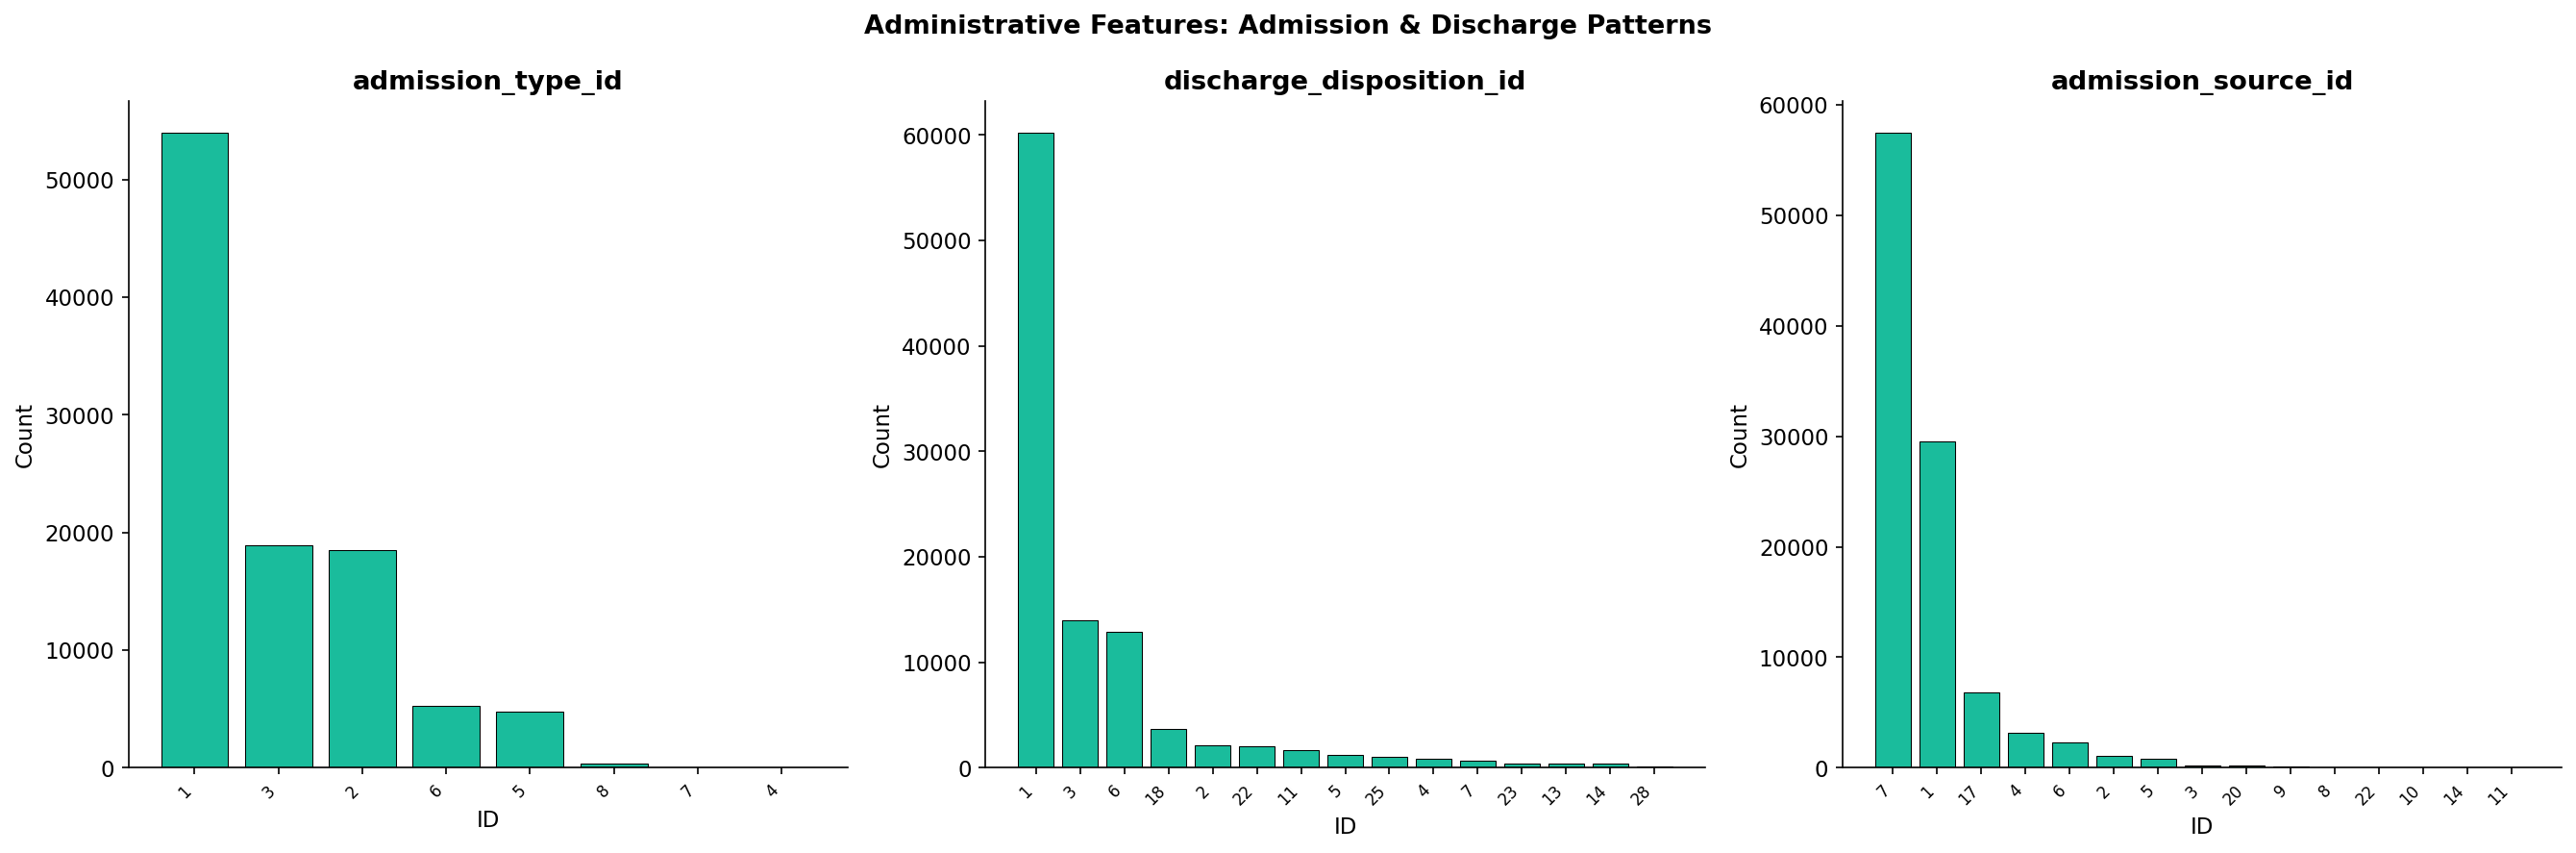

Saved: 10_admission_discharge.png


In [15]:
admin_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, admin_cols):
    vc = df[col].value_counts().head(15)
    ax.bar(vc.index.astype(str), vc.values, color='#1abc9c', edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('ID')
    ax.set_ylabel('Count')
    ax.set_xticklabels(vc.index.astype(str), rotation=45, ha='right', fontsize=8)

    # Chi-square vs target
    ct = pd.crosstab(df[col], df['readmitted'])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"{col}: chi2={chi2:.2f}, p={p:.4e} — {'SIGNIFICANT' if p < 0.05 else 'not significant'}")

plt.suptitle('Administrative Features: Admission & Discharge Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/10_admission_discharge.png", bbox_inches='tight')
plt.show()
print("Saved: 10_admission_discharge.png")

## 15. High-Missing Features: weight, max_glu_serum, A1Cresult
Columns with > 80% missing. Missingness pattern vs target determines whether to drop or encode as binary signal — following FinRiskGuard EXT_SOURCE_1 pattern.


=== weight (missing: 96.9%) ===
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Readmission rate — present: 58.40%, missing: 45.69%
Delta: 12.71pp — SIGNAL (encode missingness)

=== max_glu_serum (missing: 94.7%) ===
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Readmission rate — present: 48.58%, missing: 45.95%
Delta: 2.63pp — SIGNAL (encode missingness)

=== A1Cresult (missing: 83.3%) ===
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Readmission rate — present: 43.93%, missing: 46.52%
Delta: 2.59pp — SIGNAL (encode missingness)


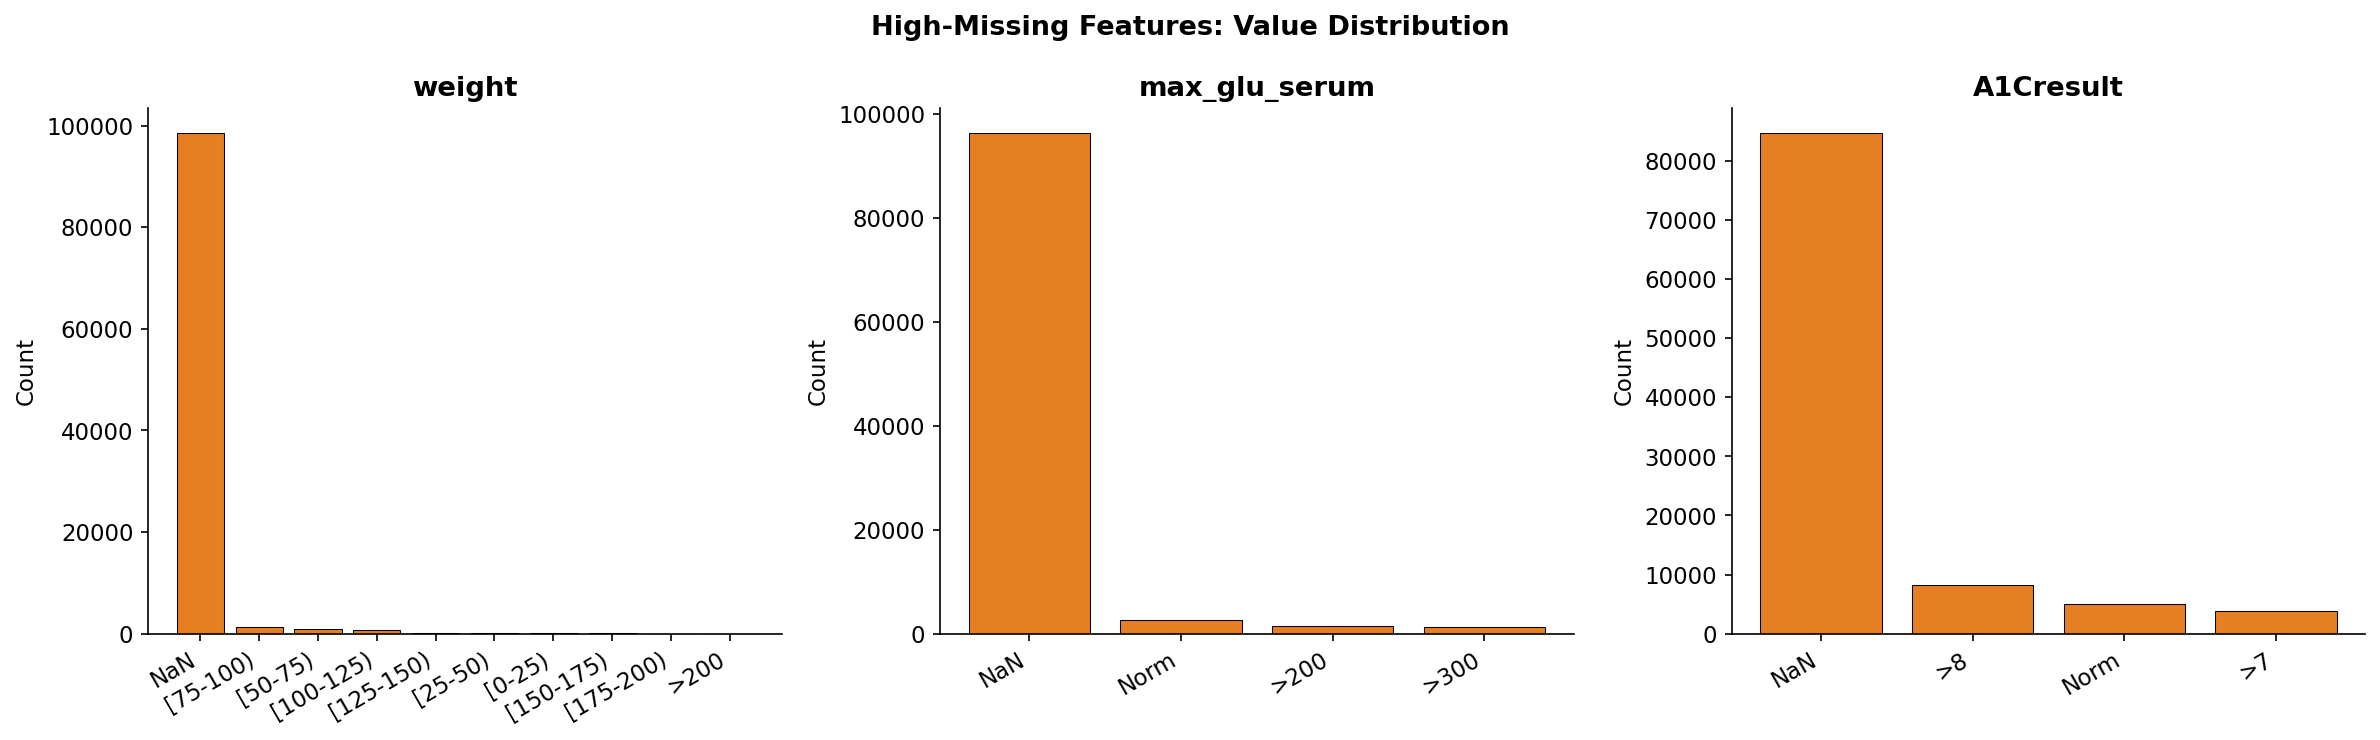

Saved: 11_high_missing_features.png


In [16]:
high_miss = ['weight', 'max_glu_serum', 'A1Cresult']

for col in high_miss:
    print(f"\n=== {col} (missing: {df[col].isna().mean()*100:.1f}%) ===")
    print(df[col].value_counts(dropna=False).to_string())

    # Readmission rate: missing vs present
    df[f'{col}_missing'] = df[col].isna().astype(int)
    miss_rate = df.groupby(f'{col}_missing')['readmitted'].apply(
        lambda x: (x != 'NO').sum() / len(x) * 100
    )
    print(f"Readmission rate — present: {miss_rate.get(0, float('nan')):.2f}%, missing: {miss_rate.get(1, float('nan')):.2f}%")
    delta = abs(miss_rate.get(0, 0) - miss_rate.get(1, 0))
    print(f"Delta: {delta:.2f}pp — {'SIGNAL (encode missingness)' if delta > 2 else 'noise (safe to drop)'}")

# Cleanup temp cols
df.drop(columns=[f'{c}_missing' for c in high_miss], inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, high_miss):
    vc = df[col].value_counts(dropna=False)
    vc.index = vc.index.astype(str).fillna('NaN')
    ax.bar(vc.index, vc.values, color='#e67e22', edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xticklabels(vc.index, rotation=30, ha='right')
    ax.set_ylabel('Count')

plt.suptitle('High-Missing Features: Value Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/11_high_missing_features.png", bbox_inches='tight')
plt.show()
print("Saved: 11_high_missing_features.png")

## 16. Multi-Visit Patient Analysis
Patients with repeated encounters create temporal correlation. If the same patient appears in train and test, label leakage occurs. This cell quantifies the risk and establishes the case for patient-level splitting.

=== Multi-Visit Statistics ===
Single-visit patients   : 54,745
Multi-visit patients    : 16,773
Max visits per patient  : 40
Rows from multi-visit   : 47,021 (46.2%)

Readmission rate by visit number:
visit_number
1   39.9000
2   54.7100
3   63.4800
4   68.3200
5   69.6900
6   74.1100


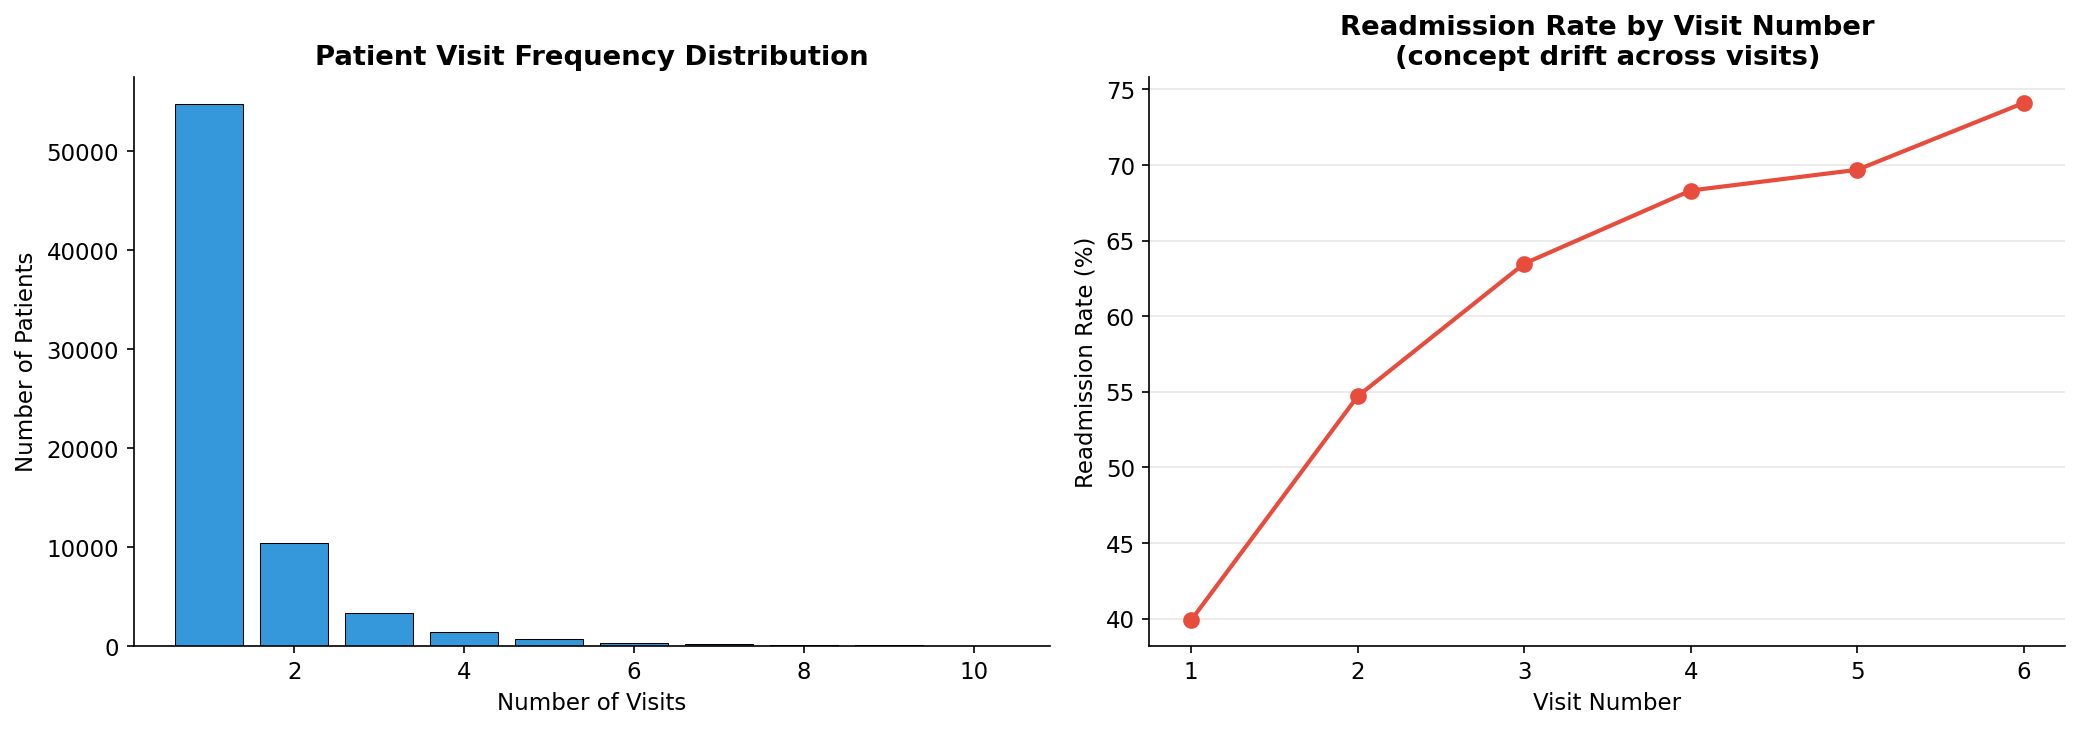

Saved: 12_multi_visit_analysis.png


In [17]:
visit_counts = df['patient_nbr'].value_counts()
df['visit_number'] = df.groupby('patient_nbr').cumcount() + 1
df['total_visits']  = df['patient_nbr'].map(visit_counts)

print("=== Multi-Visit Statistics ===")
print(f"Single-visit patients   : {(visit_counts == 1).sum():,}")
print(f"Multi-visit patients    : {(visit_counts > 1).sum():,}")
print(f"Max visits per patient  : {visit_counts.max()}")
print(f"Rows from multi-visit   : {df[df['total_visits'] > 1].shape[0]:,} ({df[df['total_visits'] > 1].shape[0]/len(df)*100:.1f}%)")

# Readmission rate by visit number
readmit_by_visit = df[df['visit_number'] <= 6].groupby('visit_number')['readmitted'].apply(
    lambda x: (x != 'NO').sum() / len(x) * 100
)
print(f"\nReadmission rate by visit number:")
print(readmit_by_visit.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

visit_dist = visit_counts.value_counts().sort_index().head(10)
axes[0].bar(visit_dist.index, visit_dist.values, color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Patient Visit Frequency Distribution', fontweight='bold')

axes[1].plot(readmit_by_visit.index, readmit_by_visit.values,
             marker='o', color='#e74c3c', linewidth=2, markersize=7)
axes[1].set_xlabel('Visit Number')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate by Visit Number\n(concept drift across visits)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/12_multi_visit_analysis.png", bbox_inches='tight')
plt.show()

df.drop(columns=['visit_number', 'total_visits'], inplace=True)
print("Saved: 12_multi_visit_analysis.png")

## 17. EDA Summary — Key Findings for DriftSentinel
Consolidated findings that directly inform preprocessing, drift simulation, and adversarial testing design.

In [19]:
summary = {
    "Dataset shape"                  : f"101,766 rows × 50 columns",
    "Memory"                         : "48.51 MB",
    "Target classes"                 : "NO / <30 / >30 (imbalanced)",
    "Duplicate encounters"           : "0 — clean unique IDs",
    "Multi-visit patients"           : "23.5% — patient-level split required",
    "Critical high-missing (>80%)"   : "weight (96.9%), max_glu_serum (94.8%), A1Cresult (83.3%)",
    "Moderate missing (>30%)"        : "medical_specialty (49.1%), payer_code (39.6%)",
    "Diagnosis columns cardinality"  : "diag_1: 716, diag_2: 748, diag_3: 789 unique codes",
    "Medication columns"             : "23 cols — No/Steady/Up/Down encoding",
    "Numeric columns"                : "13 integer features — skewness varies",
    "Drift simulation strategy"      : "visit_number-based or encounter_id-order temporal split",
    "Label leakage risk"             : "High — same patient in train+test corrupts evaluation",
}

print("=" * 65)
print("EDA SUMMARY — DriftSentinel: Diabetes 130-US Dataset")
print("=" * 65)
for k, v in summary.items():
    print(f"  {k:<40} : {v}")
print("=" * 65)
print(f"\nFigures saved to: {FIGURE_DIR}")


EDA SUMMARY — DriftSentinel: Diabetes 130-US Dataset
  Dataset shape                            : 101,766 rows × 50 columns
  Memory                                   : 48.51 MB
  Target classes                           : NO / <30 / >30 (imbalanced)
  Duplicate encounters                     : 0 — clean unique IDs
  Multi-visit patients                     : 23.5% — patient-level split required
  Critical high-missing (>80%)             : weight (96.9%), max_glu_serum (94.8%), A1Cresult (83.3%)
  Moderate missing (>30%)                  : medical_specialty (49.1%), payer_code (39.6%)
  Diagnosis columns cardinality            : diag_1: 716, diag_2: 748, diag_3: 789 unique codes
  Medication columns                       : 23 cols — No/Steady/Up/Down encoding
  Numeric columns                          : 13 integer features — skewness varies
  Drift simulation strategy                : visit_number-based or encounter_id-order temporal split
  Label leakage risk                       : H